# Imports

In [349]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression  # o Ridge, Lasso
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from matplotlib import pyplot as plt

# Constantes

In [350]:
DATA_PATH = r'D:\Projects\sweet-cherry-study\notebooks\dataset_dias_latencia.csv'
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.6, 0.2, 0.2
RANDOM_STATE = 117

# Carga de los datos

In [351]:
dataset = pd.read_csv(DATA_PATH)
# Filtrando por variedad
# dataset = dataset[dataset["variedad_id"].isin([1])]
# dataset = dataset.drop(columns=["variedad_id"])
# Filtrando por zona
# dataset = dataset[dataset["zona_id"].isin([0,1,2])]
# dataset = dataset.drop(columns=["zona_id"])
dataset.head()

,tratamiento_comb,duracion_latencia_dias,absorbancia,concentracion_almidon_mg_por_g,peso_yema_mg,peso_fresco,peso_seco,porcentaje_humedad,zona_id,variedad_id,tratamiento_entrada_id,tratamiento_salida_id,chill_25_uta,chill_50_uta,chill_75_uta,chill_100_uta,chill_25_simple,chill_50_simple,chill_75_simple,chill_100_simple
0,zn+eth + dormex 3% + break,117.0,NaN,NaN,NaN,0.4124,0.2157,52.303589,2,1,2,7,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
1,fsh + dormex 2% + 2% ac. mineral,113.0,NaN,NaN,NaN,0.3628,0.1819,50.137817,2,1,1,8,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
2,control + erger 5% + nca 6%,110.0,NaN,NaN,NaN,0.3180,0.1591,50.031447,2,1,0,11,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
3,zn+u+eth + control,121.0,NaN,NaN,NaN,0.5819,0.2839,48.788452,2,1,3,6,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
4,ethephon + erger 5% + nca 6%,120.0,NaN,NaN,NaN,0.3340,0.1667,49.910180,2,1,4,11,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0


In [352]:
print(len(dataset))

279


# Split

In [353]:
train_df, temp_df = train_test_split(
    dataset, train_size=TRAIN_SIZE, random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=TEST_SIZE / (TEST_SIZE + VAL_SIZE), random_state=RANDOM_STATE
)


# Imputación de valores faltantes

In [354]:
num_cols = [
    "absorbancia",
    "concentracion_almidon_mg_por_g",
    "peso_yema_mg",
    "peso_fresco",
    "peso_seco",
    "porcentaje_humedad",
]

df_train_imputed = train_df.copy()

medianas_map = {}
for col in num_cols:
    median_value = df_train_imputed[col].median()
    medianas_map[col] = median_value
    df_train_imputed[col] = df_train_imputed[col].fillna(median_value)

# Comprobación rápida
print(df_train_imputed[num_cols].isna().sum())


absorbancia                       0
concentracion_almidon_mg_por_g    0
peso_yema_mg                      0
peso_fresco                       0
peso_seco                         0
porcentaje_humedad                0
dtype: int64


In [355]:
# Imputamos val y test segun esos valores
def impute_with_median(df, medianas_map):
    df_imputed = df.copy()
    for col, median_value in medianas_map.items():
        df_imputed[col] = df_imputed[col].fillna(median_value)
    return df_imputed

val_df_imputed = impute_with_median(val_df, medianas_map)
test_df_imputed = impute_with_median(test_df, medianas_map)

# Escalando y encoding de variables

In [356]:
target_col = "duracion_latencia_dias"

numeric_features = [
    "absorbancia",
    "concentracion_almidon_mg_por_g",
    "peso_yema_mg",
    "peso_fresco",
    "peso_seco",
    "porcentaje_humedad",
    "chill_25_uta",
    "chill_50_uta",
    "chill_75_uta",
    "chill_100_uta",
    "chill_25_simple",
    "chill_50_simple",
    "chill_75_simple",
    "chill_100_simple",
]

categorical_features = [
    "zona_id",
    "variedad_id",
    "tratamiento_entrada_id",
    "tratamiento_salida_id",
]

categorical_features = [x for x in categorical_features if x in train_df.columns]


In [357]:
# Pipeline para numéricas:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

# Pipeline para categóricas:
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

# ColumnTransformer que aplica lo anterior
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [358]:
x_train, y_train = df_train_imputed.drop(columns=[target_col]), df_train_imputed[target_col]
x_val, y_val = val_df_imputed.drop(columns=[target_col]), val_df_imputed[target_col]
x_test, y_test = test_df_imputed.drop(columns=[target_col]), test_df_imputed[target_col]

In [359]:
x_train

,tratamiento_comb,absorbancia,concentracion_almidon_mg_por_g,peso_yema_mg,peso_fresco,peso_seco,porcentaje_humedad,zona_id,variedad_id,tratamiento_entrada_id,tratamiento_salida_id,chill_25_uta,chill_50_uta,chill_75_uta,chill_100_uta,chill_25_simple,chill_50_simple,chill_75_simple,chill_100_simple
120,"fsh + dormex 1,5% + 2% ac. mineral",1.0374,22.208643,200.4,0.5719,0.2765,48.347613,7,0,1,16,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
129,zn+eth + erger 5% + nca 4%,0.5523,11.076132,200.2,0.6573,0.3072,46.736650,7,0,2,12,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
25,aba + dormex 2% + break,1.0374,22.208643,200.4,0.4799,0.2436,50.760575,3,1,5,15,378.0,808.0,1318.0,1636.0,256.0,672.0,1094.0,1308.0
170,ethephon + dormex 2% + break,1.2611,27.428372,200.4,0.6938,0.3232,46.584030,5,2,4,15,450.0,932.5,1468.5,1825.0,329.0,852.0,1284.0,1571.0
276,"zn+eth + dormex 1,5% + 2% ac. mineral",1.0393,22.330203,200.2,0.6290,0.2973,47.265501,7,2,2,16,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,ethephon + erger 5% + nca 4%,1.0374,22.208643,200.4,0.4597,0.2117,46.051773,4,2,4,12,450.0,923.0,1459.0,1799.5,329.0,813.0,1245.0,1496.0
275,ethephon + control,0.9343,19.923664,200.0,0.7321,0.3450,47.124710,7,2,4,6,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
87,"fsh + dormex 1,5% + 2% ac. mineral",1.0374,22.208643,200.4,0.7591,0.3396,44.737189,4,2,1,16,450.0,923.0,1459.0,1799.5,329.0,813.0,1245.0,1496.0
80,"fsh + dormex 1,5% + 2% ac. mineral",1.0374,22.208643,200.4,0.9307,0.4096,44.009885,4,2,1,16,450.0,923.0,1459.0,1799.5,329.0,813.0,1245.0,1496.0


Baseline usar el promedio del target

In [360]:
# Baseline: siempre predecir la media de y_train
baseline_pred = np.full_like(y_val, fill_value=y_train.mean(), dtype=float)

MAE_baseline = mean_absolute_error(y_val, baseline_pred)
print("MAE baseline (predice media):", MAE_baseline)


MAE baseline (predice media): 5.522562018819504


# Modelado (Linear Regression)

In [361]:
# Modelo de regresión lineal
regressor = LinearRegression()

# Pipeline completo: preprocesar -> modelo
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", regressor),
])

# Entrenar
model.fit(x_train, y_train)

# Evaluar rápido en validación
from sklearn.metrics import mean_absolute_error, r2_score
y_val_pred = model.predict(x_val)
# Check nan in predictions
print("MAE val:", mean_absolute_error(y_val, y_val_pred))
print("R^2 val:", r2_score(y_val, y_val_pred))

MAE val: 3.7614939350650247
R^2 val: 0.4521550952539225


# Modelado (Ridge)

In [362]:
# Modelo de regresión lineal
regressor = Ridge(1.0)
# Si quieres regularización:
# from sklearn.linear_model import Ridge
# regressor = Ridge(alpha=1.0)

# Pipeline completo: preprocesar -> modelo
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", regressor),
])

# Entrenar
model.fit(x_train, y_train)

# Evaluar rápido en validación
from sklearn.metrics import mean_absolute_error, r2_score
y_val_pred = model.predict(x_val)
# Check nan in predictions
print("MAE val:", mean_absolute_error(y_val, y_val_pred))
print("R^2 val:", r2_score(y_val, y_val_pred))

MAE val: 3.7978805570645804
R^2 val: 0.4402209559683845


# Modelado (Random Forest)

In [363]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),  # el mismo que usaste en la regresión lineal
    ("regressor", RandomForestRegressor(
        n_estimators=500,
        max_depth=5,          # controla complejidad, puedes jugar con esto
        min_samples_leaf=5,   # evita sobreajuste con pocos datos
        random_state=42,
        n_jobs=-1
    )),
])

rf_model.fit(x_train, y_train)

y_val_pred_rf = rf_model.predict(x_val)

MAE_val_rf = mean_absolute_error(y_val, y_val_pred_rf)
r2_val_rf = r2_score(y_val, y_val_pred_rf)

print("RF MAE val:", MAE_val_rf)
print("RF R^2 val:", r2_val_rf)


RF MAE val: 4.341289824898364
RF R^2 val: 0.29199253068227815


# Modelado (XGBoost)

In [364]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),  # el mismo que usaste antes
    ("regressor", XGBRegressor(
        n_estimators=300,          # pocos árboles por tamaño de muestra
        learning_rate=0.05,        # pasitos chicos
        max_depth=3,               # árboles bajos = menos overfit
        min_child_weight=5,        # evita splits con muy pocos datos
        subsample=0.8,             # bagging de filas
        colsample_bytree=0.8,      # bagging de columnas
        reg_lambda=1.0,            # L2
        reg_alpha=0.0,             # L1 (puedes luego probar >0)
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",        # rápido en CPU
        n_jobs=-1,
    )),
])

xgb_model.fit(x_train, y_train)

y_val_pred_xgb = xgb_model.predict(x_val)

MAE_val_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
r2_val_xgb = r2_score(y_val, y_val_pred_xgb)

print("XGB MAE val:", MAE_val_xgb)
print("XGB R^2 val:", r2_val_xgb)


XGB MAE val: 3.894515173775809
XGB R^2 val: 0.38496529427117765


# Resumen y selección del mejor modelo

In [365]:
# Imprimamos un resumen general
print("Resumen de resultados en validación:")
print(f"Baseline MAE: {MAE_baseline:.4f} y (R^2: 0.0000)")
print(f"Linear Regression MAE: {mean_absolute_error(y_val, y_val_pred):.4f} y (R^2: {r2_score(y_val, y_val_pred):.4f})")
print(f"Ridge MAE: {mean_absolute_error(y_val, model.predict(x_val)):.4f} y (R^2: {r2_score(y_val, model.predict(x_val)):.4f})")
print(f"Random Forest MAE: {MAE_val_rf:.4f} y (R^2: {r2_val_rf:.4f})")
print(f"XGBoost MAE: {MAE_val_xgb:.4f} y (R^2: {r2_val_xgb:.4f})")

Resumen de resultados en validación:
Baseline MAE: 5.5226 y (R^2: 0.0000)
Linear Regression MAE: 3.7979 y (R^2: 0.4402)
Ridge MAE: 3.7979 y (R^2: 0.4402)
Random Forest MAE: 4.3413 y (R^2: 0.2920)
XGBoost MAE: 3.8945 y (R^2: 0.3850)


In [366]:
# Elijamos el mejor modelo automáticamente segun R2 en validación
model_scores = {
    "Linear Regression": r2_score(y_val, y_val_pred),
    "Ridge": r2_score(y_val, model.predict(x_val)),
    "Random Forest": r2_val_rf,
    "XGBoost": r2_val_xgb,
}
best_model_name = max(model_scores, key=model_scores.get)
print(f"Mejor modelo en validación: {best_model_name} con R^2 = {model_scores[best_model_name]:.4f}")

Mejor modelo en validación: Linear Regression con R^2 = 0.4402


In [367]:
if best_model_name == "Linear Regression":
    best_model = model
elif best_model_name == "Ridge":
    best_model = model
elif best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = xgb_model


In [368]:
# Evaluemos el mejor modelo en test
y_test_pred = best_model.predict(x_test)
MAE_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f"Desempeño en test del mejor modelo ({best_model_name}):")
print(f"MAE test: {MAE_test:.4f}")
print(f"R^2 test: {r2_test:.4f}")


Desempeño en test del mejor modelo (Linear Regression):
MAE test: 3.3548
R^2 test: 0.4504


In [369]:
# Write to a file a summary of the results
with open("model_quicktest_results.txt", "w", encoding='UTF-8') as f:
    f.write("Resumen de resultados en validación:\n")
    f.write(f"Baseline MAE: {MAE_baseline:.4f} y (R^2: 0.0000)\n")
    f.write(f"Linear Regression MAE: {mean_absolute_error(y_val, y_val_pred):.4f} y (R^2: {r2_score(y_val, y_val_pred):.4f})\n")
    f.write(f"Ridge MAE: {mean_absolute_error(y_val, model.predict(x_val)):.4f} y (R^2: {r2_score(y_val, model.predict(x_val)):.4f})\n")
    f.write(f"Random Forest MAE: {MAE_val_rf:.4f} y (R^2: {r2_val_rf:.4f})\n")
    f.write(f"XGBoost MAE: {MAE_val_xgb:.4f} y (R^2: {r2_val_xgb:.4f})\n")
    f.write(f"Mejor modelo en validación: {best_model_name} con R^2 = {model_scores[best_model_name]:.4f}\n")
    f.write(f"\nDesempeño en test del Baseline (predice media):\n")
    f.write(f"MAE test: {mean_absolute_error(y_test, np.full_like(y_test, fill_value=y_train.mean(), dtype=float)):.4f}\n")
    f.write(f"R^2 test: {0.0:.4f}\n")
    f.write(f"Desempeño en test del mejor modelo ({best_model_name}):\n")
    f.write(f"MAE test: {MAE_test:.4f}\n")
    f.write(f"R^2 test: {r2_test:.4f}\n")

    # Añadamos las metricas obtenidas al evaluar por variedad
    f.write("\nDesempeño por variedad en test:\n")
    variedades = x_test["variedad_id"].unique()
    for variedad in variedades:
        mask = x_test["variedad_id"] == variedad
        y_true_var = y_test[mask]
        y_pred_var = y_test_pred[mask]
        mae_var = mean_absolute_error(y_true_var, y_pred_var)
        # Veamos el mae si solo usamos el promedio
        mae_var_baseline = mean_absolute_error(y_true_var, np.full_like(y_true_var, fill_value=y_train.mean(), dtype=float))
        f.write(f"Variedad {variedad}: MAE = {mae_var:.4f} | BaselineMAE = {mae_var_baseline:.4f}\n")


In [373]:
variedades_id_to_text = {
    0: 'regina',
    1: 'santina',
    2: 'kordia',
}

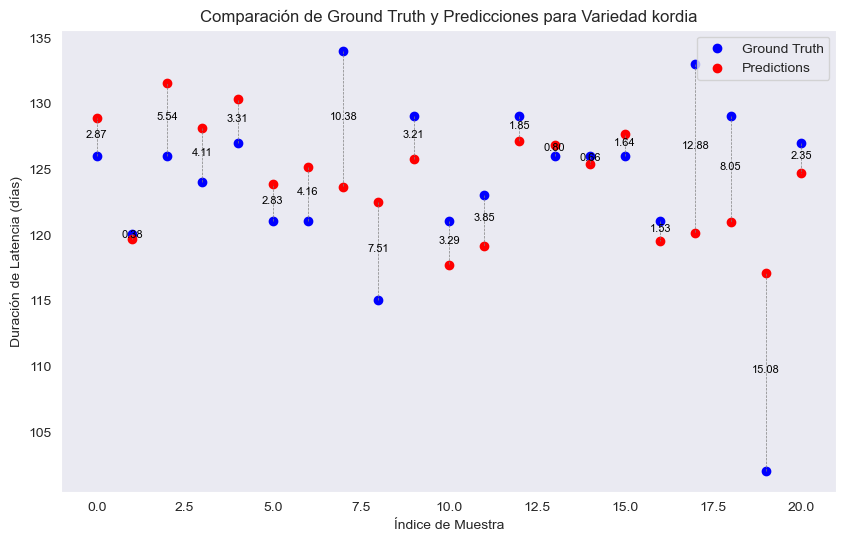

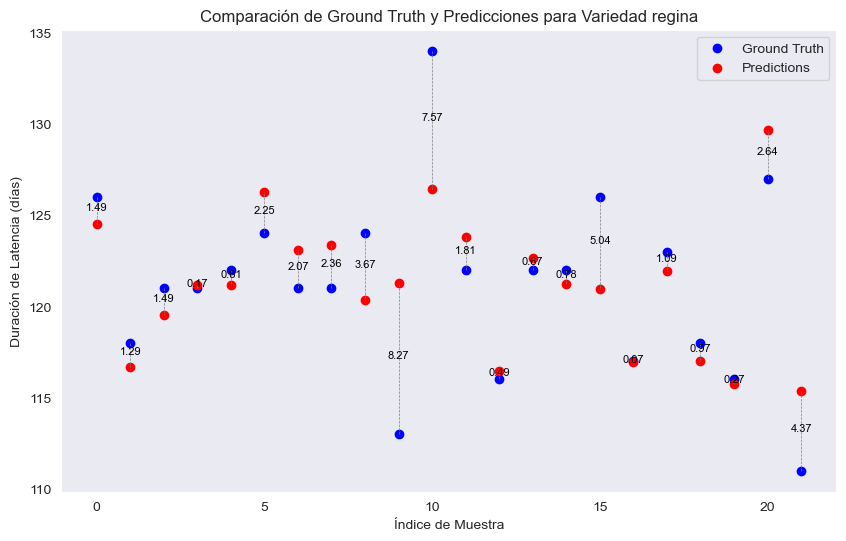

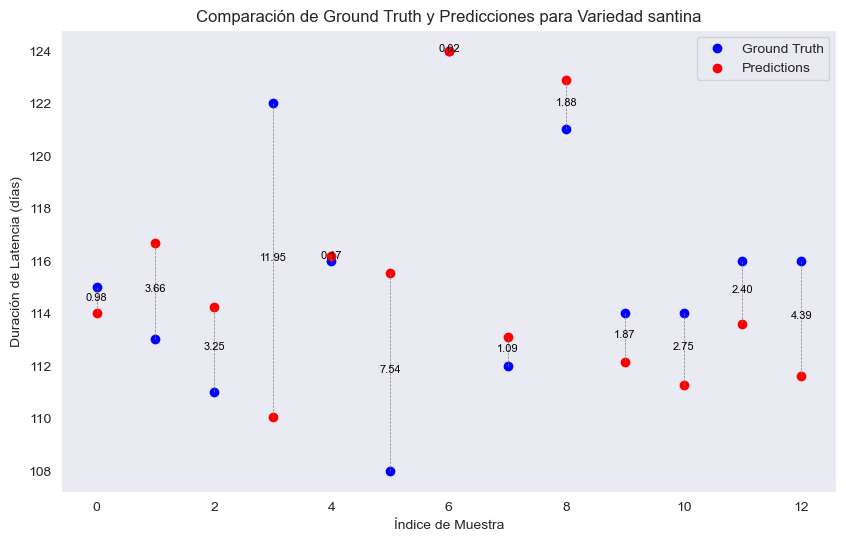

In [374]:
# Hagamos un grafico agrupado por variedad mostrando la comparacion del ground truth con el label de 3 puntos por variedad de manera aleatoria
# Dibuja una linea entre los puntos de ground truth y predicciones para cada punto y anota la diferencia en cada punto
variedades = x_test["variedad_id"].unique()
for variedad in variedades:
    mask = x_test["variedad_id"] == variedad
    y_true_var = y_test[mask]
    y_pred_var = y_test_pred[mask]

    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(y_true_var)), y_true_var, color='blue', label='Ground Truth')
    plt.scatter(range(len(y_pred_var)), y_pred_var, color='red', label='Predictions')

    for i in range(len(y_true_var)):
        plt.plot([i, i], [y_true_var.iloc[i], y_pred_var[i]], color='gray', linestyle='--', linewidth=0.5)
        plt.text(i, (y_true_var.iloc[i] + y_pred_var[i]) / 2, f"{abs(y_true_var.iloc[i] - y_pred_var[i]):.2f}",
                 fontsize=8, color='black', ha='center')

    plt.title(f'Comparación de Ground Truth y Predicciones para Variedad {variedades_id_to_text[variedad]}')
    plt.xlabel('Índice de Muestra')
    plt.ylabel('Duración de Latencia (días)')
    plt.legend()
    plt.grid()
    plt.show()

In [375]:
# Para todas las muestras de test quiero saber si el modelo esta prediciendo por encima o por debajo del valor real
# y quiero un resumen de cuantas predicciones estan por encima y cuantas por debajo
above_count = 0
below_count = 0
for true, pred in zip(y_test, y_test_pred):
    if pred > true:
        above_count += 1
    else:
        below_count += 1
print(f"Predicciones por encima del valor real: {above_count}")
print(f"Predicciones por debajo del valor real: {below_count}")
# Ahora quiero eso mismo pero desagregado por variedad
variedades = x_test["variedad_id"].unique()
for variedad in variedades:
    mask = x_test["variedad_id"] == variedad
    y_true_var = y_test[mask]
    y_pred_var = y_test_pred[mask]
    above_count_var = 0
    below_count_var = 0
    n = 0
    for true, pred in zip(y_true_var, y_pred_var):
        n+=1
        if pred > true:
            above_count_var += 1
        else:
            below_count_var += 1
    print(f"Variedad {variedades_id_to_text[variedad]} ({n}):")
    print(f"  Predicciones por encima del valor real: {above_count_var}")
    print(f"  Predicciones por debajo del valor real: {below_count_var}")

Predicciones por encima del valor real: 26
Predicciones por debajo del valor real: 30
Variedad kordia (21):
  Predicciones por encima del valor real: 10
  Predicciones por debajo del valor real: 11
Variedad regina (22):
  Predicciones por encima del valor real: 10
  Predicciones por debajo del valor real: 12
Variedad santina (13):
  Predicciones por encima del valor real: 6
  Predicciones por debajo del valor real: 7
